<img src="../../images/arm_logo.png" width=250 alt="ARM Logo"></img>

# The All-Sky Imager (ASI) Sky Cover data product ([ASISKYCOVER](https://armgov.svcs.arm.gov/capabilities/instruments/asi))

---

## Overview
This notebook demonstrates the use of the two main datasets generated by the All-Sky Imager (ASI) Sky Cover data product (ASISKYCOVER; [Silber et al., 2026](https://doi.org/10.5194/egusphere-2025-6134)) supplemented by a companion ASISKYCOVER dataset to examine cloud cover properties over the ARM Bankhead National Forest (BNF) site on December 17, 2025.

1. Introduction to ASISKYCOVER
1. How to access the data and load using Xarray
1. Processing, analysis, and visualization


---

### Imports

In [1]:
import os

import act
import matplotlib
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as patches

from skimage.draw import disk
from matplotlib.gridspec import GridSpec

## Overview of ASISKYCOVER

The ASISKYCOVER data product provides cloud cover information derived from ARM's all-sky imager (ASI) instruments distributed in ARM deployments. The ASISKYCOVER processing is consistent with the processing of images of the ASI's predecessor (the total-sky imager - TSI) in aspects such as the unique 80 degrees off-zenith coverage and the surface observer frame of reference corrections (weighing) of cloudy pixels. These and other processing methods enable a smooth transition between the instruments, extending ARM's now-acquired long-term cloud cover records. The ASISKYCOVER processing provides new, upgraded, and unique capabilities such as machine-learning (ML) segmentation of image pixels; ML classification of Solar disk state (solar disk seen/blocked by clouds); masking of artifacts such as bugs and dirt; cloud cover for near-zenith angles facilitating comparisons with ARM's zenith-pointing instruments; and uncertainty metrics.

## How to Access ASISKYCOVER Data from ARM

### Use the ARM Live API to Download the Data, using ACT

The Atmospheric Data Community Toolkit (ACT) has a helpful module to interface with the data server:
* [Download Data API](https://arm-doe.github.io/ACT/API/generated/act.discovery.html#module-act.discovery)

### Setup our Download Query
Before downloading our data, we need to make sure we have an ARM Data Account, and ARM Live token. Both of these can be found using this link:
- [ARM Live Signup](https://adc.arm.gov/armlive/livedata/home)

Once you sign up, you will see your token. Copy and replace that where we have `arm_username` and `arm_password` below.

Here, we will use ASISKYCOVER's time series and cloud mask datasets supplemented by the companion (b0-level) dataset, so we also need the names of those three datastreams, which are `bnfasiskycoverM1.b1` and `bnfasicldmaskM1.b1`, and `bnfasiskycoverM1.b0` respectively, representing:
- the site (BNF) and facility (M1)
    - This information corresponds to the Bankhead National Forest main site in Alabama
- the product class (asiskycover and asicldmask)
    - Those are the products described in this notebook
- the data level (b0 and b1)
    - The b0 level dataset serves as an intermediate or companion dataset to the main two b1 level products

In [2]:
arm_username = os.getenv("ARM_USERNAME")
arm_password = os.getenv("ARM_PASSWORD")

cc_datastream = "bnfasiskycoverM1.b1"
cmsk_datastream = "bnfasicldmaskM1.b1"
supp_datastream = "bnfasiskycoverM1.b0"

start_date = "2025-12-17T00:00:00"
end_date = "2025-12-17T23:59:00"

askycover = act.discovery.download_arm_data(arm_username,
                                             arm_password,
                                             cc_datastream,
                                             start_date,
                                             end_date)

asicldmask = act.discovery.download_arm_data(arm_username,
                                             arm_password,
                                             cmsk_datastream,
                                             start_date,
                                             end_date)

asisupp = act.discovery.download_arm_data(arm_username,
                                          arm_password,
                                          supp_datastream,
                                          start_date,
                                          end_date)

[DOWNLOADING] bnfasiskycoverM1.b1.20251217.125430.nc

If you use these data to prepare a publication, please cite:

Flynn, D. All Sky Imager (ASISKYCOVER), 2025-12-17 to 2025-12-17, Bankhead
National Forest, AL, USA; Long-term Mobile Facility (BNF), Bankhead National
Forest, AL, AMF3 (Main Site) (M1). Atmospheric Radiation Measurement (ARM) User
Facility.

[DOWNLOADING] bnfasicldmaskM1.b1.20251217.125430.nc

If you use these data to prepare a publication, please cite:

Flynn, D. All Sky Imager (ASICLDMASK), 2025-12-17 to 2025-12-17, Bankhead
National Forest, AL, USA; Long-term Mobile Facility (BNF), Bankhead National
Forest, AL, AMF3 (Main Site) (M1). Atmospheric Radiation Measurement (ARM) User
Facility.

[DOWNLOADING] bnfasiskycoverM1.b0.20251217.125430.nc
[DOWNLOADING] bnfasiskycoverM1.b0.20251217.130000.nc
[DOWNLOADING] bnfasiskycoverM1.b0.20251217.140000.nc
[DOWNLOADING] bnfasiskycoverM1.b0.20251217.150000.nc
[DOWNLOADING] bnfasiskycoverM1.b0.20251217.160000.nc
[DOWNLOADING] bnfas

### Read and examine data files

In [ ]:
asc_ds = xr.open_mfdataset(askycover)
ascmsk_ds = xr.open_mfdataset(asicldmask)
ascsupp_ds = xr.open_mfdataset(asisupp)

---

We can start by examining the sky cover time series dataset. Note the various percentages and pixel clouds for all or certain cloud types and well as the various uncertainty fields. As expected from ARM data standards, all data fields are fully annotated.

In [6]:
asc_ds

<xarray.Dataset> Size: 485kB
Dimensions:                                          (time: 1166)
Coordinates:
  * time                                             (time) datetime64[ns] 9kB ...
Data variables: (12/56)
    base_time                                        datetime64[ns] 8B ...
    time_offset                                      (time) datetime64[ns] 9kB dask.array<chunksize=(1166,), meta=np.ndarray>
    percent_cloud                                    (time) float64 9kB dask.array<chunksize=(1166,), meta=np.ndarray>
    percent_clear                                    (time) float64 9kB dask.array<chunksize=(1166,), meta=np.ndarray>
    percent_cloud_thin                               (time) float64 9kB dask.array<chunksize=(1166,), meta=np.ndarray>
    percent_cloud_intermediate                       (time) float64 9kB dask.array<chunksize=(1166,), meta=np.ndarray>
    ...                                               ...
    weighted_near_zenith_cloud_thick_count           (time) float64 9kB dask.array<chunksize=(1166,), meta=np.ndarray>
    weighted_near_zenith_uncertainty_masked_count    (time) float64 9kB dask.array<chunksize=(1166,), meta=np.ndarray>
    weighted_near_zenith_uncertainty_low_prob_count  (time) float64 9kB dask.array<chunksize=(1166,), meta=np.ndarray>
    lat                                              float32 4B ...
    lon                                              float32 4B ...
    alt                                              float32 4B ...
Attributes: (12/30)
    command_line:                                             asiskycover --m...
    Conventions:                                              ARM-1.3
    process_version:                                          asiskycover-1.2.0
    dod_version:                                              asiskycover-b1-1.1
    input_datastreams:                                        bnfasiskyimageM...
    site_id:                                                  bnf
    ...                                                       ...
    sun_area_mask_size_pixels:                                100
    solar_zenith_angle_mean_site_bias:                        3.814607729664518
    solar_azimuth_angle_mean_site_bias:                       -3.928335895643327
    summary:                                                  The ASISKYCOVER...
    keywords:                                                 ARM, ground-bas...
    history:                                                  created by user...

We can also examine the cloud mask dataset. Note that we have the same number of timestamps, each corresponding to a single point in the time series data file.

In [7]:
ascmsk_ds

<xarray.Dataset> Size: 11GB
Dimensions:              (time: 1166, y: 1536, x: 1536, img_coords: 2)
Coordinates:
  * time                 (time) datetime64[ns] 9kB 2025-12-17T12:54:30 ... 20...
  * img_coords           (img_coords) int32 8B 0 1
Dimensions without coordinates: y, x
Data variables:
    base_time            datetime64[ns] 8B ...
    time_offset          (time) datetime64[ns] 9kB dask.array<chunksize=(9,), meta=np.ndarray>
    cloud_mask           (time, y, x) float32 11GB dask.array<chunksize=(1, 1536, 1536), meta=np.ndarray>
    image_center_coords  (time, img_coords) float64 19kB dask.array<chunksize=(9, 2), meta=np.ndarray>
    solar_disk_coords    (time, img_coords) float64 19kB dask.array<chunksize=(9, 2), meta=np.ndarray>
    eff_image_diameter   (time) float64 9kB dask.array<chunksize=(9,), meta=np.ndarray>
    solar_zenith_angle   (time) float64 9kB dask.array<chunksize=(9,), meta=np.ndarray>
    solar_azimuth_angle  (time) float64 9kB dask.array<chunksize=(9,), meta=np.ndarray>
    lat                  float32 4B ...
    lon                  float32 4B ...
    alt                  float32 4B ...
Attributes: (12/30)
    command_line:                                             asiskycover --m...
    Conventions:                                              ARM-1.3
    process_version:                                          asiskycover-1.2.0
    dod_version:                                              asicldmask-b1-1.1
    input_datastreams:                                        bnfasiskyimageM...
    site_id:                                                  bnf
    ...                                                       ...
    sun_area_mask_size_pixels:                                100
    solar_zenith_angle_mean_site_bias:                        3.814607729664518
    solar_azimuth_angle_mean_site_bias:                       -3.928335895643327
    summary:                                                  The ASISKYCOVER...
    keywords:                                                 ARM, ground-bas...
    history:                                                  created by user...

Finally, let's examine the data in the companion dataset. This supplemental dataset has a much larger data volume than the main product datasets, and hence it is provided on an hourly basis (as opposed to daily files in the main two datasets). This dataset can be used if users are interested in examining the raw ML output, the input features (essentially the raw ASI image and its red-to-blue channel ratio), and the ML algorithm decision probability, which can be used, for example, to customize thresholds for uncertain pixels or perform a different type of analysis using ML algorithm output.

In [8]:
ascsupp_ds

<xarray.Dataset> Size: 66GB
Dimensions:                (time: 1166, nfeatures: 4, y: 1536, x: 1536,
                            sun_nfeatures: 66, img_coords: 2)
Coordinates:
  * time                   (time) datetime64[ns] 9kB 2025-12-17T12:54:30 ... ...
  * img_coords             (img_coords) int32 8B 0 1
Dimensions without coordinates: nfeatures, y, x, sun_nfeatures
Data variables: (12/20)
    base_time              (time) datetime64[ns] 9kB 2025-12-17 ... 2025-12-17
    time_offset            (time) datetime64[ns] 9kB dask.array<chunksize=(9,), meta=np.ndarray>
    features_desc          (time, nfeatures) |S50 233kB dask.array<chunksize=(11, 4), meta=np.ndarray>
    features               (time, y, x, nfeatures) float32 44GB dask.array<chunksize=(1, 96, 1536, 4), meta=np.ndarray>
    sun_features_desc      (time, sun_nfeatures) |S50 4MB dask.array<chunksize=(11, 66), meta=np.ndarray>
    sun_features           (time, sun_nfeatures) float64 616kB dask.array<chunksize=(9, 66), meta=np.ndarray>
    ...                     ...
    eff_image_diameter     (time) float64 9kB dask.array<chunksize=(9,), meta=np.ndarray>
    solar_zenith_angle     (time) float64 9kB dask.array<chunksize=(9,), meta=np.ndarray>
    solar_azimuth_angle    (time) float64 9kB dask.array<chunksize=(9,), meta=np.ndarray>
    lat                    (time) float32 5kB 34.34 34.34 34.34 ... 34.34 34.34
    lon                    (time) float32 5kB -87.34 -87.34 ... -87.34 -87.34
    alt                    (time) float32 5kB 293.0 293.0 293.0 ... 293.0 293.0
Attributes: (12/29)
    command_line:                                             asiskycover --m...
    Conventions:                                              ARM-1.3
    process_version:                                          asiskycover-1.2.0
    dod_version:                                              asiskycover-b0-1.1
    input_datastreams:                                        bnfasiskyimageM...
    site_id:                                                  bnf
    ...                                                       ...
    sun_area_mask_size_pixels:                                100
    solar_zenith_angle_mean_site_bias:                        3.814607729664518
    solar_azimuth_angle_mean_site_bias:                       -3.928335895643327
    summary:                                                  The ASISKYCOVER...
    keywords:                                                 ARM, ground-bas...
    history:                                                  created by user...

### Processing, analysis and visualization

---

Before examining the ASISKYCOVER output, we need to define some handy processing and plotting routines that we will use below.

In [22]:
def set_circle_area_label(label_arr, img_c, radius, set_in_circle=True, label_value=0):
    """
    Set labels in/out of a circle within a given label array.
    
    Parameters
    ----------
    label_arr : numpy.ndarray
        The input label array (x and y dim shape matching corresponding image)
    img_c : array_like
        Center indices for image (or the center of the requested circle) as [x, y]
    radius : int
        Radius of the circle in pixels.
    set_in_circle : bool, optional
        If True label values are set inside the circle; outside the circle if False.
        Default is True.
    label_value : int or scalar, optional
        Label value to set in circle area (include or exclude). Default is 0.
        
    Returns
    -------
    label_out : numpy.ndarray
        The input label array with modified labels within the specified circle.
        Same shape as input label_arr.
    """
    # Create a mask for the circle (may change shape if needed)
    rr, cc = disk(img_c, radius, shape=label_arr.shape)
    if set_in_circle:
        mask_arr_val, mask_val = False, True
    else:
        mask_arr_val, mask_val = True, False
    mask = np.full(label_arr.shape, mask_arr_val, dtype=bool)
    mask[rr, cc] = mask_val

    # Apply the condition to pixels within the circle
    label_out = label_arr.copy()
    label_out[mask] = label_value

    return label_out

def zenith_angle_to_pixel_radius(theta, img_size, theta_in_deg=True):
    """
    Convert zenith angle to radial distance in pixels for a fisheye camera with 180-degree FOV.
    
    Parameters
    ----------
    theta : float
        Zenith angle in radians or degrees.
    img_size : int
        The effective size (diameter) of the image in pixels. Using the smaller of the 2 axes.
    theta_in_deg : bool, optional
        If True, input angle is in degrees; if False, in radians. Default is True.
        
    Returns
    -------
    r : float
        Radial distance in pixels.
    r_proj : float
        Radial distance of projection in pixels (r * sin(theta)).
    """
    if theta_in_deg:
        theta = theta * np.pi / 180
    R_max = img_size / 2
    k = R_max / (np.pi / 2)
    r = k * theta
    r_proj = r * np.sin(theta)
    return r, r_proj
    

def set_fov_mask(img_shape, max_zenith_angle, img_size, img_c):
    """
    Create a field of view (FOV) mask for the given image based on the maximum zenith angle.
    
    Parameters
    ----------
    img_shape : tuple of int
        Shape of the image as (height, width) for which the FOV mask is to be created.
    max_zenith_angle : float
        The maximum zenith angle to determine the radius of the FOV mask.
    img_size : int
        The effective size (diameter) of the image in pixels.
    img_c : array_like
        The center coordinates (x, y) of the image.
        
    Returns
    -------
    fov_mask : numpy.ndarray
        The FOV mask with the same height and width as the input image shape, 
        where the FOV area is labeled with 0 and outside area with 1.
    """
    r_max, _ = zenith_angle_to_pixel_radius(max_zenith_angle, img_size)
    fov_mask = set_circle_area_label(np.ones(img_shape, dtype='bool'), img_c, r_max)
    return fov_mask
    
def plot_skycover_tseries(asc_ds: xr.Dataset, time_rng: tuple = None, plot_fpath: str = None, add_full_fov: bool = True,
                          add_classes: bool = True, add_narrow_fov: bool = True, mask_night: bool = True):
    """
    Plot sky cover time series from All Sky Imager (ASI) dataset with twilight periods.
    
    Parameters
    ----------
    asc_ds : xarray.Dataset
        Dataset containing ASI cloud cover data with time, solar_zenith_angle, 
        and various cloud percentage variables.
    time_rng : tuple of datetime-like, optional
        Time range to plot as (start_time, end_time). If None, uses sunrise to sunset or full time series.
        Default is None.
    plot_fpath : str, optional
        File path to save the plot. If None, plot is not saved. Default is None.
    add_full_fov : bool, optional
        If True, plot total cloud cover for full field of view. Default is True.
    add_classes : bool, optional
        If True, plot cloud classes (thin, intermediate, thick). Default is True.
    add_narrow_fov : bool, optional
        If True, plot near-zenith cloud cover. Default is True.
    mask_night : bool, optional
        If True, mask nighttime periods (SZA > 96°) with white overlay. Default is True.
        
    Returns
    -------
    fig : matplotlib.figure.Figure
        The figure object containing the plot.
    ax : matplotlib.axes.Axes
        Primary axes object for cloud cover data.
    ax2 : matplotlib.axes.Axes
        Secondary y-axis for sun state data.
    """
    time_arr = asc_ds["time"].values
    sza = asc_ds["solar_zenith_angle"].values

    # determine times a certain SZA value is crossed (in this case, twilight times)
    def set_sunrise_sunset(time_arr, sza, sza_cutoff):
        if sza.max() > sza_cutoff:
            tmp_arr = np.argwhere(sza >= sza_cutoff)
            tmp_arr2 = np.argwhere(sza < sza_cutoff)
            if sza[0] > sza_cutoff:
                sunset, sunrise = time_arr[tmp_arr2[-1].item()], time_arr[tmp_arr2[0].item()]
            else:
                sunset, sunrise = time_arr[tmp_arr[0].item()], time_arr[tmp_arr[-1].item()]
            return sunset, sunrise
        else:
            return None, None
    sunset, sunrise = set_sunrise_sunset(time_arr, sza, 90.0)
    sunset_naut, sunrise_naut = set_sunrise_sunset(time_arr, sza, 96.0)
    sunset_astr, sunrise_astr = set_sunrise_sunset(time_arr, sza, 102.0)
    sunset_night, sunrise_night = set_sunrise_sunset(time_arr, sza, 108.0)
    
    fig, ax = plt.subplots(figsize=(16, 4), tight_layout=True)

    # add sunrise and sunset times to background
    def set_sunset_patch(time_arr, sunset, sunrise):
        if sunset is not None:
            if sunset < sunrise:
                rect = patches.Rectangle((sunset, -10.0), (sunrise - sunset), 120.0, facecolor='k', alpha=0.1)
                ax.add_patch(rect)
            else:
                rect = patches.Rectangle((time_arr[0], -10.0), (sunrise - time_arr[0]), 120.0, facecolor='k', alpha=0.1)
                ax.add_patch(rect)
                rect = patches.Rectangle((sunset, -10.0), (time_arr[-1] - sunset), 120.0, facecolor='k', alpha=0.1)
                ax.add_patch(rect)
    set_sunset_patch(time_arr, sunset, sunrise)
    set_sunset_patch(time_arr, sunset_naut, sunrise_naut)
    set_sunset_patch(time_arr, sunset_astr, sunrise_astr)
    set_sunset_patch(time_arr, sunset_night, sunrise_night)

    plot_arr_da = xr.DataArray(np.full(time_arr.size, np.nan), coords={"time": ("time", time_arr)})
    plot_un_da = xr.DataArray(np.full(time_arr.size, np.nan), coords={"time": ("time", time_arr)})
    rel_times = np.isin(plot_arr_da["time"].values, asc_ds["time"].values)
    if add_full_fov:
        plot_arr_da[rel_times] = asc_ds["percent_cloud"].values
        plot_un_da[rel_times] = asc_ds["uncertainty_total"].values
        plot_arr_da.plot(c='DarkSlateGray', label=r"ASI (total)", linewidth=4, alpha=0.6, ax=ax)
        ax.fill_between(plot_arr_da["time"].values,
                        plot_arr_da.values - plot_un_da.values,
                        plot_arr_da.values + plot_un_da.values,
                        facecolor='DarkSlateGray', alpha=0.35, label=r"ASI (total) $\pm$ Uncertainty")
    if add_classes:
       asc_ds["percent_cloud_thin"].plot(c='SeaGreen', label=r"ASI (thin)", linewidth=4, alpha=0.6, ax=ax)
       asc_ds["percent_cloud_intermediate"].plot(c='LawnGreen', label=r"ASI (intermediate)", linewidth=4, alpha=0.6, ax=ax)
       asc_ds["percent_cloud_thick"].plot(c='Yellow', label=r"ASI (thick)", linewidth=4, alpha=0.6, ax=ax)
    if add_narrow_fov:
        plot_arr_da[rel_times] = asc_ds["near_zenith_percent_cloud"].astype(float).values
        plot_un_da[rel_times] = asc_ds["near_zenith_uncertainty_total"].astype(float).values
        plot_arr_da.plot(c='DarkViolet', label=r"ASI 5° off-zenith (total)", linewidth=4, alpha=0.6, ax=ax)
        ax.fill_between(plot_arr_da["time"].values,
                        plot_arr_da.values - plot_un_da.values,
                        plot_arr_da.values + plot_un_da.values,
                        facecolor='DarkViolet', alpha=0.35, label=r"ASI 5° off-zenith (total) $\pm$ Uncertainty")

    if mask_night & (sunset_naut is not None):
        rect = patches.Rectangle((sunset_naut, -10.0), (sunrise_naut - sunset_naut), 120.0, facecolor='w', zorder=100)
        ax.add_patch(rect)

    if time_rng:
        ax.set_xlim(time_rng)
    elif sunset is not None:
        minx = np.min((sunset, sunrise))
        maxx = np.max((sunset, sunrise))
        ax.set_xlim((minx, maxx))
    else:
        ax.set_xlim((asc_ds["time"].values[0], asc_ds["time"].values[-1]))
    ax.set_ylim((-1, 101))
    ax.set_ylabel("Cloud occurrence percentage")
    
    ax2 = ax.twinx()
    
    # Plot the solar state
    ax2.scatter(asc_ds["time"].values, asc_ds["sun_state"].where(lambda x: x>=0), s=0.5, c='DeepPink', alpha=0.6)
    ax2.set_ylim(-1, 9.3)
    ax2.set_xlim(ax.get_xlim())
    ax2.tick_params(axis='y', color='DeepPink')
    ax2.set_yticks(np.arange(0, 1.5))
    ax2.set_yticklabels(["Sun blocked", "Sol. disk seen"], color='DeepPink')
    ax.legend().set_zorder(200)

    # Save figure
    # ============================
    if plot_fpath is not None:
        fig.savefig(plot_fpath, dpi=150)

    return fig, ax, ax2
    

def plot_cld_mask(ascmsk_ds: xr.Dataset, time_index: int, asc_ds: xr.Dataset = None, ascsupp_ds: xr.Dataset = None, img: np.ndarray = None, decision_prob: np.ndarray = None, plot_fpath: str = None,
                  skip_raw_image: bool = False):
    """
    Plot cloud mask results from All Sky Imager (ASI) data with optional raw image and decision probabilities.
    
    Parameters
    ----------
    ascmsk_ds : xarray.Dataset
        Dataset containing cloud mask data with time, cloud_mask, solar angles, 
        and metadata attributes.
    time_index : int
        Time index to plot from the dataset.
    asc_ds : xarray.Dataset, optional
        Dataset containing additional ASI data like sun_state, percent_cloud, etc.
        Default is None.
    ascsupp_ds : xarray.Dataset, optional
        Supplementary dataset containing raw features and decision probabilities.
        Default is None.
    img : numpy.ndarray, optional
        Raw image array with shape (height, width, channels). If provided, 
        overrides extraction from ascsupp_ds. Default is None.
    decision_prob : numpy.ndarray, optional
        Decision probability array with shape (height, width). If provided,
        overrides extraction from ascsupp_ds. Default is None.
    plot_fpath : str, optional
        File path to save the plot. If None, plot is not saved. Default is None.
    skip_raw_image: bool, optional
        If True, skip showing the raw image.
        
    Returns
    -------
    fig : matplotlib.figure.Figure
        The figure object containing the plot(s).
    ax : list of matplotlib.axes.Axes
        List of axes objects for each subplot.
    cax : list of matplotlib.axes.Axes
        List of colorbar axes objects.
        
    Notes
    -----
    The function creates different subplot layouts depending on available data:
    - Single panel: only cloud mask
    - Two panels: cloud mask + (raw image OR decision probability)
    - Three panels: raw image + decision probability + cloud mask
    
    Cloud mask bits are decoded as:
    - Bit 0: Clear sky
    - Bit 1: Thin cloud
    - Bit 2: Intermediate cloud
    - Bit 3: Thick cloud
    - Bit 4: Masked pixels
    - Bit 5: Low confidence pixels
    - Bit 6: Image boundary mask
    """
    # Get information to create title
    image_time = ascmsk_ds["time"].values[time_index]
    image_time_str = str(image_time).replace('T', ' ')

    site = ascmsk_ds.attrs["site_id"]
    facility = ascmsk_ds.attrs["facility_id"]
    solar_zenith_angle = ascmsk_ds["solar_zenith_angle"].values[time_index]
    solar_azimuth_angle = ascmsk_ds["solar_azimuth_angle"].values[time_index]

    # extract raw image and decision probability from the corresponding b0-level data file
    if ascsupp_ds:
        ascsupp_tstep_ds = ascsupp_ds.isel(time=time_index).squeeze()

        # Extract data from dataset for the given time index
        decision_prob = ascsupp_tstep_ds["cloud_mask_confidence"].values

        # The first three features are RGB normalized between 0 and 1
        if skip_raw_image:
            img = None
        else:
            img = ascsupp_tstep_ds["features"].values[:, :, :3]

    if asc_ds:
        sun_state = asc_ds["sun_state"].values[time_index]
        sun_state_str = {
            0: "Sun blocked by cloud",
            1: "Solar disk visible"
        }.get(sun_state, "Sun outside FOV")
    
        sun_state_prob = asc_ds["sun_state_prob"].values[time_index]
        if np.isnan(sun_state_prob):
            sun_state_prob_str = "N/A"
        else:
            sun_state_prob_str = f"{sun_state_prob:.3f}"

        cloud_cover = asc_ds["percent_cloud"].values[time_index]
        uncertainty_total = asc_ds["uncertainty_total"].values[time_index]

    title_line1 = f"{site}{facility} ASI {image_time_str}"
    title_line2 = f"SZA: {solar_zenith_angle:.1f}°, solar azimuth: {solar_azimuth_angle:.1f}°"
    if asc_ds:
        title_line3 = f"{sun_state_str}, decision probability: {sun_state_prob_str}"
        title_line4 = f"Cloud cover: {cloud_cover:.1f}±{uncertainty_total:.1f}%"

    # This is low_pixel_classification_decision_probability_threshold global att
    low_prob_threshold = ascmsk_ds.attrs[
        "low_pixel_classification_decision_probability_threshold"
    ]
    low_prob_threshold = float(low_prob_threshold)

    cloud_mask = ascmsk_ds["cloud_mask"].values[time_index, :, :]
    cloud_mask = cloud_mask.astype(int)

    # Convert to bit numbers, bit 1-5
    decision_arr = np.zeros(cloud_mask.shape, dtype="int")

    decision_arr[(cloud_mask & 2**0) > 0] = 1  # bit 0 (clr) -> value 1
    decision_arr[(cloud_mask & 2**1) > 0] = 2  # bit 1 (thin) -> value 2
    decision_arr[(cloud_mask & 2**2) > 0] = 3  # bit 2 (intermed) -> value 3
    decision_arr[(cloud_mask & 2**3) > 0] = 4  # bit 3 (thick) -> value 4
    decision_arr[(cloud_mask & 2**4) > 0] = 0  # bit 4 (msk) -> value 0

    # Bit 5 of cloud_mask
    # And includes decision_arr == 0.....
    eff_msk = decision_arr == 0

    # bit 6 of cloud_mask
    bit_value = 2**5
    uncertmsk = (cloud_mask & bit_value) > 0

    # Bit 7 of cloud_mask
    bit_value = 2**6
    img_msk = (cloud_mask & bit_value) > 0

    # Center coords for time
    image_center_coords = ascmsk_ds["image_center_coords"].values[time_index]

    # Solar disk coords for time
    solar_disk_coords = ascmsk_ds["solar_disk_coords"].values[time_index]

    max_zenith_angle = ascmsk_ds.attrs["max_off_zenith_angle_in_fov"]
    max_zenith_angle = float(max_zenith_angle)
    max_near_zenith_angle = ascmsk_ds.attrs[
        "max_off_zenith_angle_in_near_zenith_fov_fields"
    ]
    max_near_zenith_angle = float(max_near_zenith_angle)

    img_size = ascmsk_ds["eff_image_diameter"].values[time_index]
    img_shape = cloud_mask.shape

    img_c = ascmsk_ds["image_center_coords"].values[time_index][::-1]  # flip to y,x
    fov_mask = set_fov_mask(img_shape, max_zenith_angle, img_size, img_c)
    nz_fov_mask = set_fov_mask(img_shape, max_near_zenith_angle, img_size, img_c)

    # Set plotting variables
    # ============================
    label_str = ["msk", "clr", "cld (thin)", "cld (intermed)", "cld (thick)"]
    cmap = plt.get_cmap("viridis", len(label_str))
    cldmask = decision_arr

    # Set figure handles
    # ============================
    nrows = 30
    
    if decision_prob is None and img is None:  # only plotting mask (single-panle figure)
        img_exist, prob_exist = False, False
        fig, ax, cax = plt.figure(figsize=(8, 8)), [], []
        gs = GridSpec(nrows=nrows, ncols=1, figure=fig)
        ax.append(fig.add_subplot(gs[: nrows - 2, 0]))
        cax.append(fig.add_subplot(gs[nrows - 1, 0]))
    elif decision_prob is not None and img is not None:
        img_exist, prob_exist = True, True
        prob_ind = 1
        fig, ax, cax = plt.figure(figsize=(16, 24)), [], []
        gs = GridSpec(nrows=nrows * 3, ncols=1, figure=fig)
        ax.append(fig.add_subplot(gs[: nrows - 2, 0]))
        ax.append(fig.add_subplot(gs[nrows + 2 : nrows * 2 - 2, 0]))
        ax.append(fig.add_subplot(gs[nrows * 2 + 2 : nrows * 3 - 2, 0]))
        cax.append(fig.add_subplot(gs[nrows * 2 - 1, 0]))
        cax.append(fig.add_subplot(gs[nrows * 3 - 1, 0]))
    else:
        if img is not None:
            img_exist = True
        else:
            img_exist = False
        if decision_prob is not None:
            prob_exist, prob_ind = True, 0
        fig, ax, cax = plt.figure(figsize=(16, 16)), [], []
        gs = GridSpec(nrows=nrows * 2, ncols=1, figure=fig)
        ax.append(fig.add_subplot(gs[: nrows - 2, 0]))
        ax.append(fig.add_subplot(gs[nrows + 2 : nrows * 2 - 2, 0]))
        if prob_ind:
            cax.append(fig.add_subplot(gs[nrows - 1, 0]))
        cax.append(fig.add_subplot(gs[nrows * 2 - 1, 0]))

    # Plot raw image
    if img_exist:
        a = ax[0].imshow(img)
        ax[0].set_title("Raw image")

    # Plot decision probability
    if prob_exist:
        a = ax[prob_ind].imshow(decision_prob, vmin=0.0, vmax=1.0, cmap="hot")
        cbar = plt.colorbar(a, orientation="horizontal", cax=cax[0])
        ax[prob_ind].grid(which="major", color="darkgray", linestyle="-", linewidth=0.5)
        ax[prob_ind].set_title("Decision probability")

    # Now plot Final mask
    # ============================
    a = ax[-1].imshow(cldmask, cmap=cmap, vmin=-0.5, vmax=len(label_str) - 0.5)

    cs = ax[-1].contourf(
        np.where(eff_msk == True, 1, (uncertmsk == False).astype(float)),
        levels=[0.0, 0.5],
        colors="none",
        hatches=["...", None],
        extend="lower",
    )
    cs._hatch_color = (1.0, 1.0, 1.0, 1.0)

    cs = ax[-1].contourf(
        (img_msk == False).astype(float),
        levels=[0.0, 0.5],
        colors="none",
        hatches=[r"\//", None],
        extend="lower",
    )
    cs._hatch_color = (1.0, 0.0, 0.0, 1.0)

    cs = ax[-1].contourf(
        ((eff_msk == True) & (img_msk == False)).astype(float),
        levels=[0.5, 1.0],
        colors="none",
#        hatches=["....", None],
        hatches=["...", None],
        extend="lower",
    )
    cs._hatch_color = (1.0, 0.0, 0.0, 1.0)

    cbar = plt.colorbar(a, orientation="horizontal", cax=cax[-1])
    cbar.set_ticks((np.arange(0, len(label_str))))
    cbar.set_ticklabels(label_str)

    ax[-1].scatter(
        image_center_coords[0],
        image_center_coords[1],
        marker="+",
        color="m",
        label="effective image center",
    )
    ax[-1].scatter(
        solar_disk_coords[0],
        solar_disk_coords[1],
        marker="*",
        color="w",
        label="solar disk (camera bias corrected)",
    )

    if False:
        ax[-1].set_title("Final mask")
        ax[-1].legend()
        cs = ax[-1].contourf(nz_fov_mask,
            levels=[0.0, 0.5],
            color="none",
            hatches=["...", None],
            extend="lower",
        )
        cs._hatch_color = (1.0, 1.0, 1.0, 1.0)

    #ax[-1].grid(which="major", color="darkgray", linestyle="-", linewidth=0.5)

    title = f"{title_line1}\n{title_line2}\n{title_line3}\n{title_line4}"
    fig.suptitle(title)

    # Save figure
    # ============================
    if plot_fpath is not None:
        fig.savefig(plot_fpath, dpi=150)

    return fig, ax, cax


Let’s start this short exploration and visualization of the data with the time series dataset. We would like to examine cloud cover variability on the examined day. We will plot the total cloud cover (all cloud classes) together with its uncertainty, the three classes (thin, intermediate, and thick), and the near-zenith output. We can use the `plot_skycover_tseries` function defined above. Note that we specify the `plot_fpath` variable to save the output plot to a file.
The plot shows and suggests:
1. Solar disk that is seen throughout most of the day, sometimes even when the scene is dominated by thick clouds (e.g., 15:00 UTC). We will examine that apparently contradicting period below.
2. A total cloud cover uncertainty exceeding 10%, which doesn't change much. This is the result of the BNF site mask required to exclude the potential influence of the trees surrounding the M1 facility on the pixel segmentation.
3. An interesting short spike in uncertainty around 16:30 UTC, which we will examine at the end of this demo.
4. A sharp increase from 0% cloud cover around sunrise and a drop to 0% at sunset. Those artifacts are mostly the result of changes in sky brightness and hue around those times, a known challenge in the pixel segmentation of sky imager data. The cloud cover drop pattern can vary from day to day and from site to site and may not necessarily drop to 0% as in this case.
5. Near-zenith cloud cover fluctuating between clear and overcast conditions (a behavior that is close to binary), resembling the point-measurement nature of ARM’s zenith-pointing instruments ([KAZR](https://armgov.svcs.arm.gov/capabilities/instruments/kazr), [CEIL](https://armgov.svcs.arm.gov/capabilities/instruments/ceil), etc.). This renders this product as a bridge between the spatial nature of the ASI and other ARM instruments, providing a basis for some of the higher-level products that might be produced in the future.

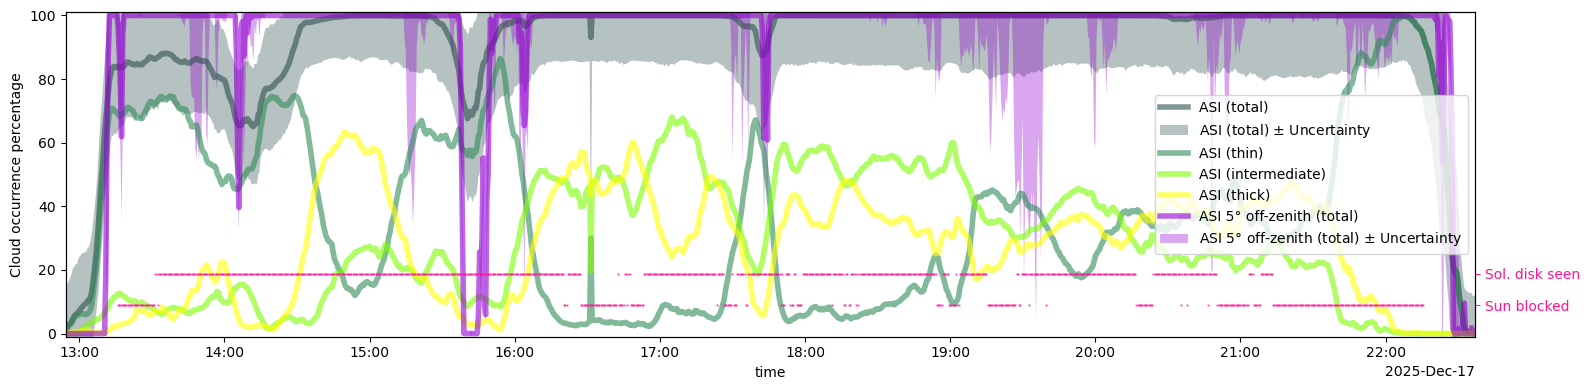

In [18]:
fig, ax, ax2 = plot_skycover_tseries(
    asc_ds,
    plot_fpath=f"asiskycover_{start_date[:start_date.find('T')]}.png",  # set to value other than None, for "auto save"
    add_full_fov=True,
    add_classes=True,
    add_narrow_fov=True,
)

As we can see here, different cloud types are suggested throughout the day. Let's examine the cloud mask at two different times, when we see different types of dominant clouds: 15:00 UTC (the intermediate and thick-dominated period mentioned above) and 15:50 UTC (thin). We will use the `plot_cld_mask` function, leveraging all the information provided in the (relatively) compact cloud mask dataset. We provide the `asc_ds` object (an optional input to this function) to print the total cloud cover and solar state decision in the figure title. The figures show masked regions (red-dotted), uncertain regions (white-dotted), solar disk center (white star), and effective image center (magenta "+" sign).

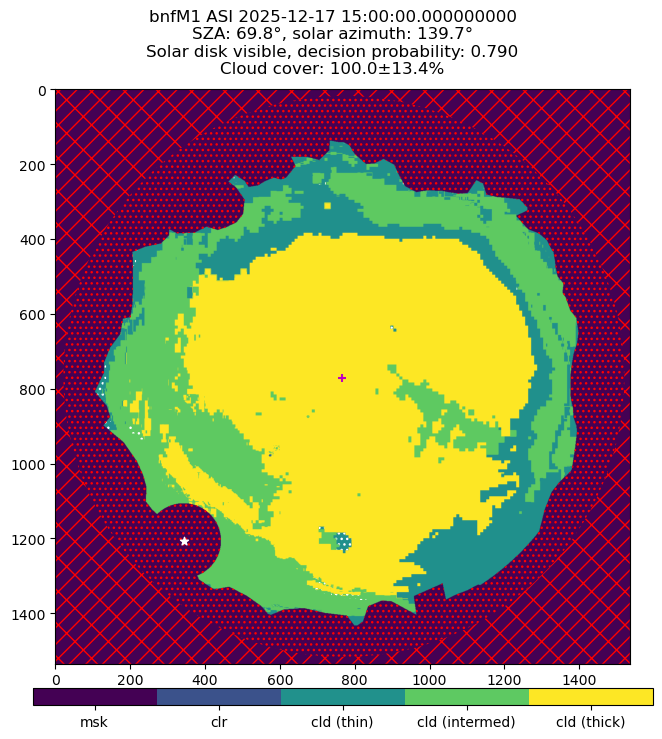

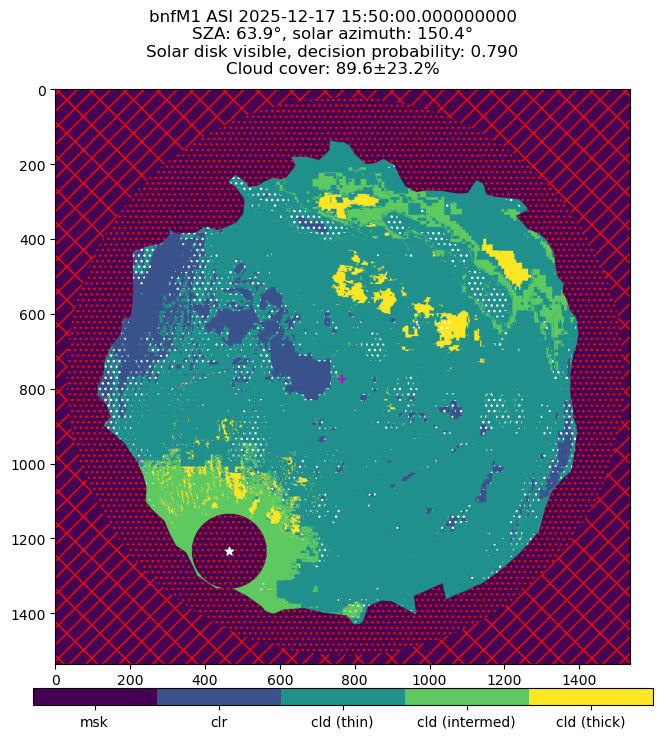

In [11]:
# thick-dominated
time_to_search = '2025-12-17T15:00:00'
sample_ind = np.argmin(np.abs(ascmsk_ds["time"].values - np.datetime64(time_to_search)))
_, _, _ = plot_cld_mask(ascmsk_ds, time_index=sample_ind, asc_ds=asc_ds, plot_fpath=f'asicldmask_{time_to_search.replace(":", "")}.png')
# thin-dominated
time_to_search = '2025-12-17T15:50:00'
sample_ind = np.argmin(np.abs(ascmsk_ds["time"].values - np.datetime64(time_to_search)))
_, _, _ = plot_cld_mask(ascmsk_ds, time_index=sample_ind, asc_ds=asc_ds, plot_fpath=f'asicldmask_{time_to_search.replace(":", "")}.png')

It is difficult to assess the robustness of the cloud mask classification without examining the raw images and decision probabilities (as per Silber et al., 2026). This is where the companion `b0` data file could be useful. Using that data file, we can examine the raw image (which can also be found in the compressed files under the corresponding `bnfasiskyimageM1.a1` dataset), as well as the decision probability of the underlying ML-algorithm ([LightGBM](https://lightgbm.readthedocs.io/en/stable/)), from which the ASISKYCOVER derives scene uncertainty (threshold of 0.5; combined with masked pixels within the 80 degrees off-zenith field-of-view). With the `b0` data and the functions defined above in hand, we can simply input the corresponding data file to the cloud mask plotting function for this purpose.
In the first example, we can see a pretty challenging classification decision indeed, which will be best validated using other datasets (e.g., [MPL](https://armgov.svcs.arm.gov/capabilities/instruments/mpl) or [HSRL](https://armgov.svcs.arm.gov/capabilities/instruments/hsrl)), and the apparent disagreement between the segmentation and solar disk state classification is resolved by the fact that the solar disk surrounding is classified as "intermediate". Evaluation of the second case generally validates the ASISKYCOVER output.

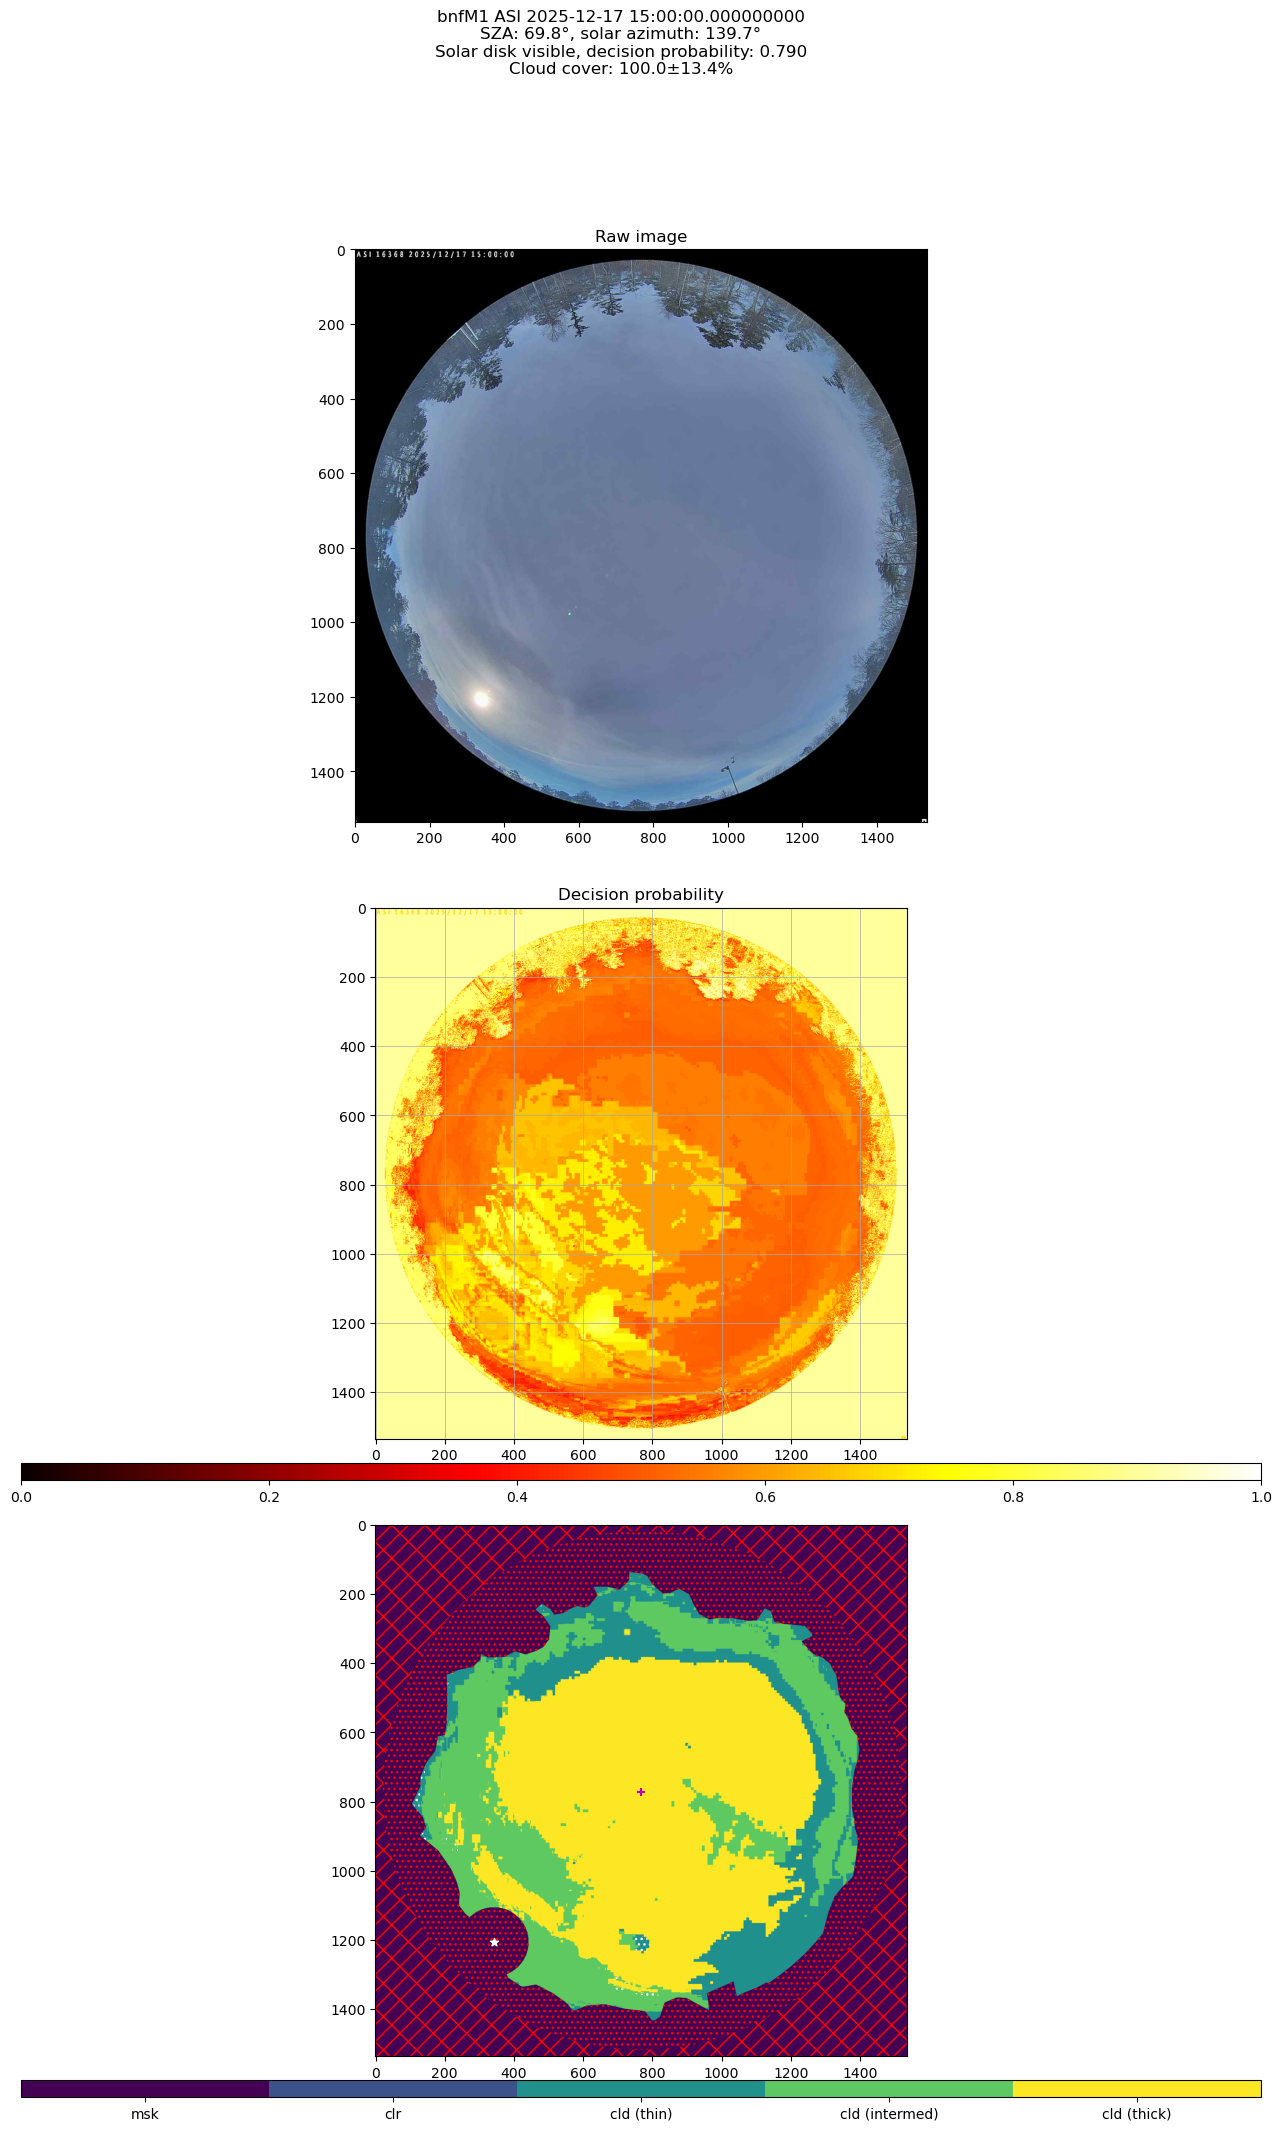

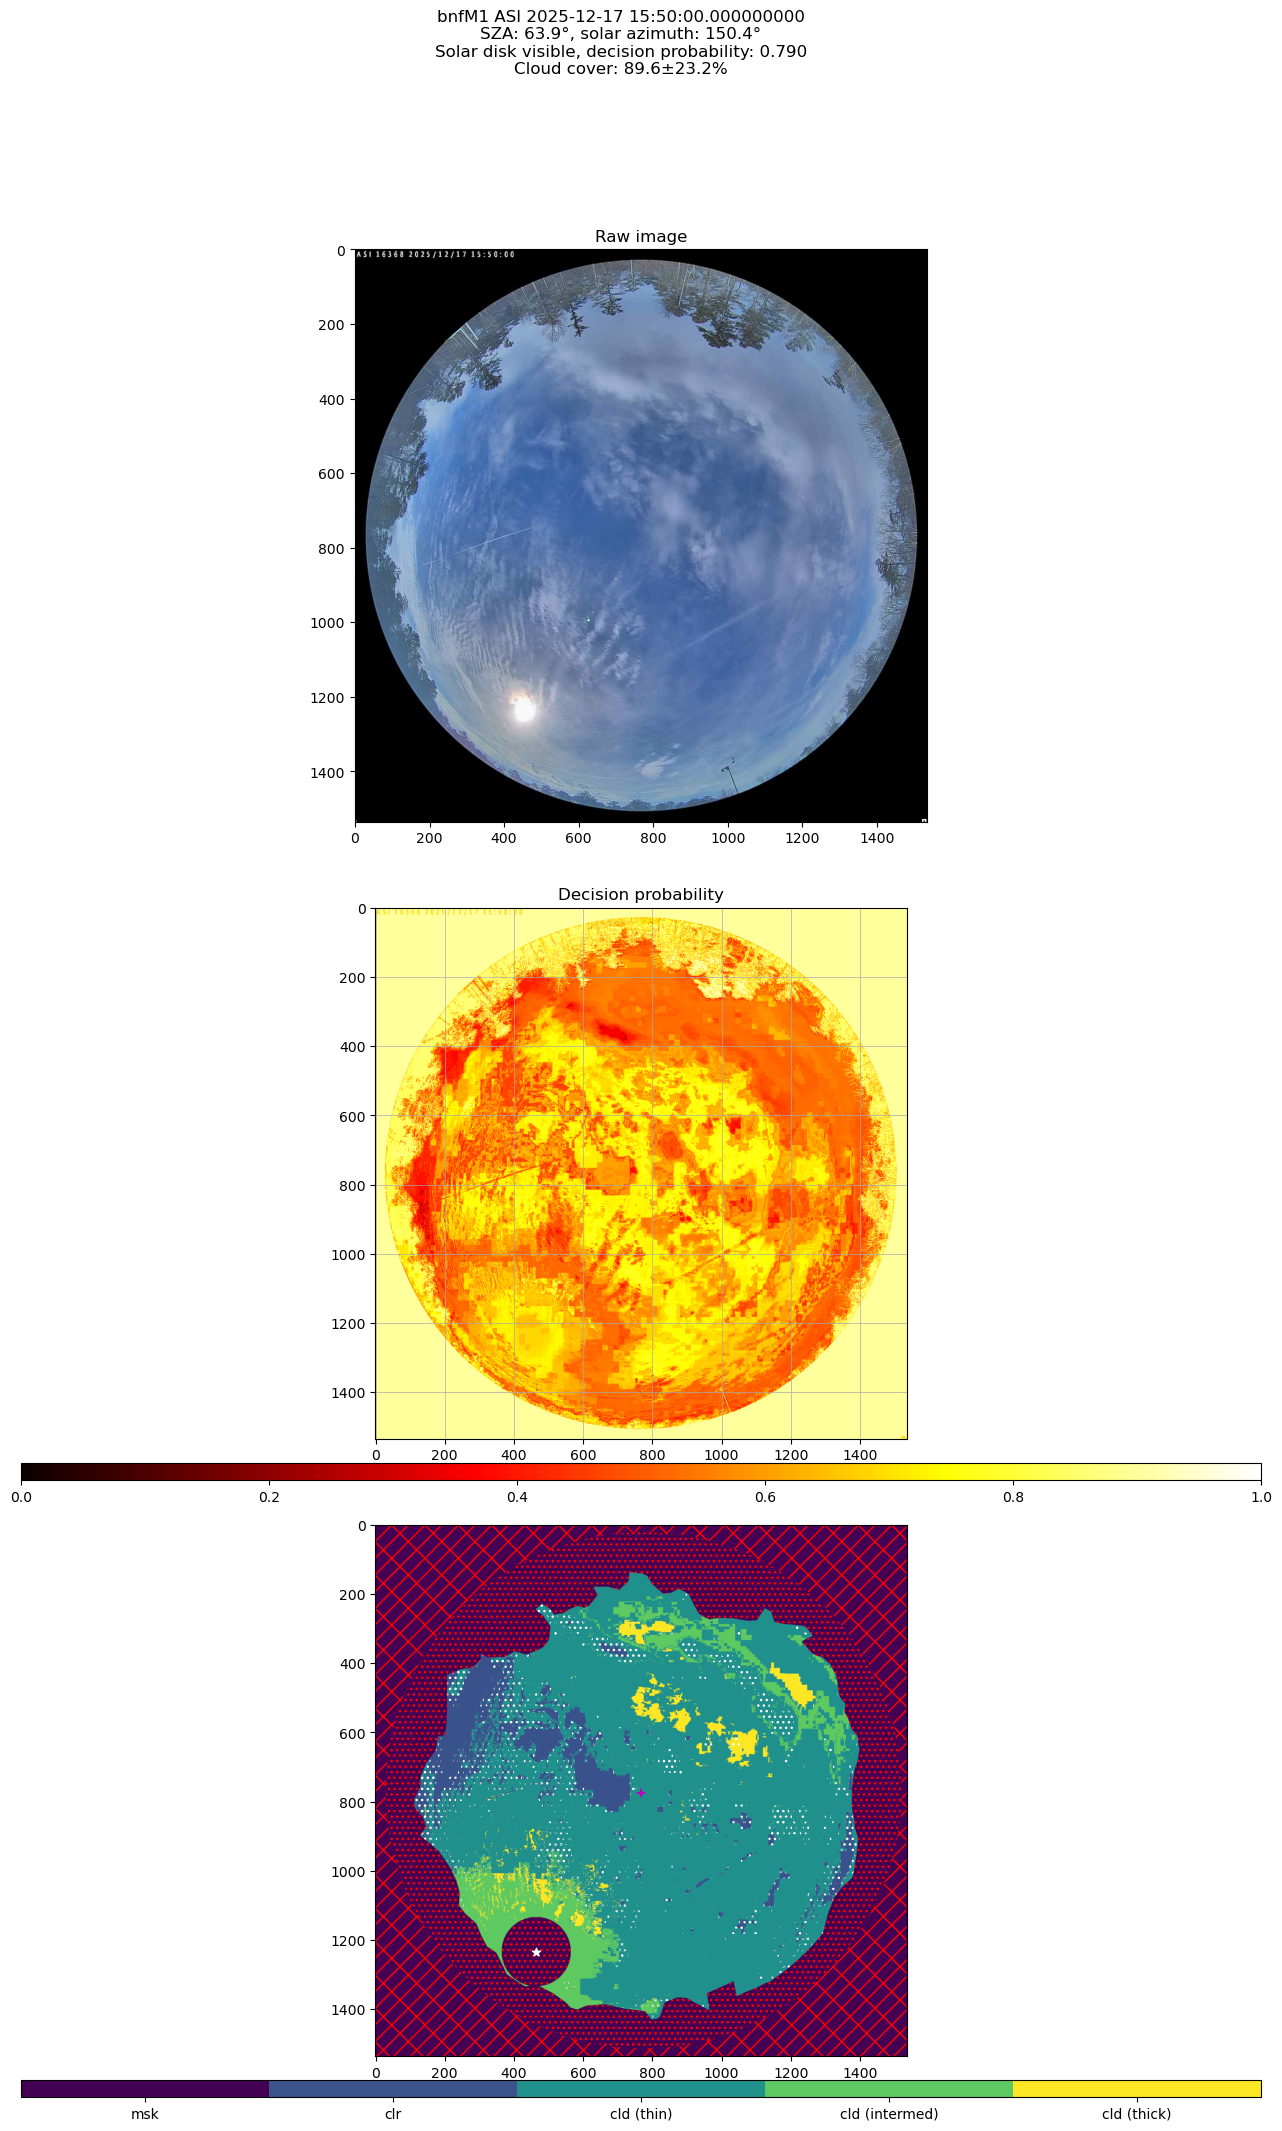

In [12]:
# intermediate and thick-dominated
time_to_search = '2025-12-17T15:00:00'
sample_ind = np.argmin(np.abs(ascmsk_ds["time"].values - np.datetime64(time_to_search)))
_, _, _ = plot_cld_mask(ascmsk_ds, time_index=sample_ind, asc_ds=asc_ds, ascsupp_ds=ascsupp_ds, plot_fpath=f'asicldmask_{time_to_search.replace(":", "")}.png')

# thin-dominated
time_to_search = '2025-12-17T15:50:00'
sample_ind = np.argmin(np.abs(ascmsk_ds["time"].values - np.datetime64(time_to_search)))
_, _, _ = plot_cld_mask(ascmsk_ds, time_index=sample_ind, asc_ds=asc_ds, ascsupp_ds=ascsupp_ds, plot_fpath=f'asicldmask_{time_to_search.replace(":", "")}.png')

To keep this demo brief, we won't dive much deeper into this analysis. We will finish by examining the specific time period around 16:30 UTC mentioned above, during which we observed a spike in cloud cover uncertainty. To examine that time stamp, we first need to find it.
Now behold, that spike appears to be the result of an ARM tech cleaning the ASI housing. Luckily, the ASISKYCOVER algorithm handles artifacts well, so pixels corresponding to the person are properly masked. (The white cloth used for that cleaning is classified incorrectly as a thick cloud, as one might expect, and might be excluded in higher-level product developments at a later stage, considering consecutive images. Anyway, for most images, even this scene, with its very high uncertainty, generally appears usable, as suggested by the resolved total cloud cover.

Maximum uncertainty of 62.3% at 2025-12-17T16:31:30.000000000


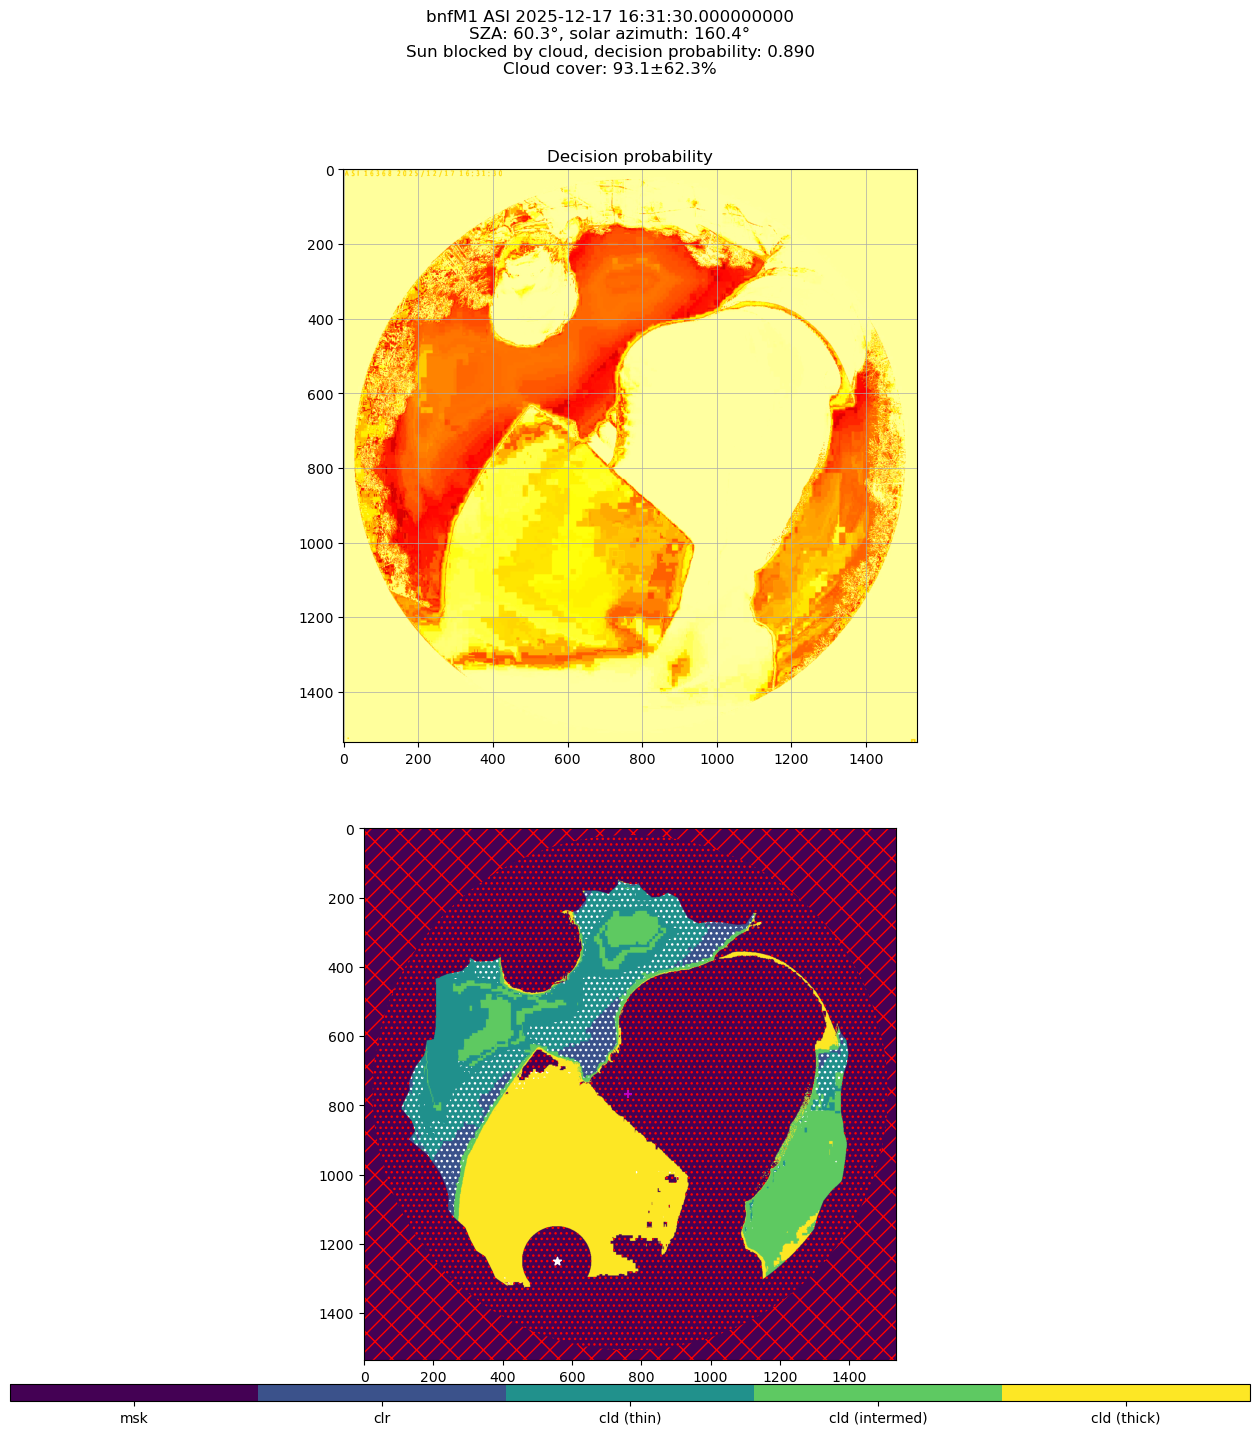

In [23]:
max_uncertainty_ind = np.argmax(asc_ds["uncertainty_total"].values)
print(f'Maximum uncertainty of {asc_ds["uncertainty_total"].values[max_uncertainty_ind]:.1f}% at {asc_ds["time"].values[max_uncertainty_ind]}')

_, _, _ = plot_cld_mask(ascmsk_ds, time_index=max_uncertainty_ind, asc_ds=asc_ds, ascsupp_ds=ascsupp_ds, skip_raw_image=True, plot_fpath=f'asicldmask_{time_to_search.replace(":", "")}.png')